In [1]:
import numpy as np
import xarray as xr
import pandas as pd
from scipy.stats import moment
import matplotlib.colors as mcolors
from matplotlib.ticker import MultipleLocator, AutoMinorLocator



import matplotlib.pyplot as plt
import calendar
import matplotlib.patches as mpatches
import seaborn as sns

from pylab import rcParams
rcParams['axes.labelweight'] = 'bold'
rcParams['axes.labelsize'] = 'x-large'
rcParams['axes.titlesize'] = 'xx-large'
rcParams['axes.titleweight'] = 'bold'

In [2]:
def decode_time(filepath):
    ds = xr.open_dataset(filepath, decode_times=False)
    units, reference_date = ds.time.attrs['units'].split('since')
    ds['time'] = pd.date_range(start=reference_date, periods=ds.sizes['time'], freq='MS')
    return ds

In [3]:
def calculate_deciles(data):
    # Flatten the data to 1D array for qcut
    flattened_data = data.flatten()
    # Calculate deciles using qcut
    deciles, bins = pd.qcut(flattened_data, qs, labels=False, retbins=True)
    # Reshape the result back to the original data shape
    return deciles.reshape(data.shape)

def calculate_monthly_deciles(ds, variable_name):
    # Get the shape of the data
    n_months = ds['time'].size
    lat_size = ds['lat'].size
    lon_size = ds['lon'].size
    
    # Create an empty array to hold the decile values
    deciles_array = np.empty((n_months, lat_size, lon_size))
    
    # Loop through each month and calculate deciles
    for i in range(n_months):
        month_data = ds[variable_name].isel(time=i).values
        deciles_array[i, :, :] = calculate_deciles(month_data)
    
    # Create a new DataArray for deciles
    dec = xr.DataArray(
        deciles_array,
        coords=[ds['time'], ds['lat'], ds['lon']],
        dims=['time', 'lat', 'lon']
    )
    
    return dec

In [4]:
def calculate_quantiles(data):
    # Flatten the data to 1D array for qcut
    flattened_data = data.flatten()
    # Calculate deciles using qcut
    deciles, bins = pd.qcut(flattened_data, qs, labels=False, retbins=True)
    # Reshape the result back to the original data shape
    return deciles.reshape(data.shape)


In [5]:
def compute_tp_by_quantiles(tp, sst_qs, qs, start_time, end_time):
    """
    Compute `tp` values based on SST quantiles for a given time slice.

    Parameters:
    - tp: xarray DataArray containing the `tp` data.
    - sst_qs: quantile-based segmentation array derived from SST.
    - qs: number of quantiles.
    - start_time: str, start of the time slice (e.g., '2014-07').
    - end_time: str, end of the time slice (e.g., '2016-06').

    Returns:
    - tp_by_qs: 2D numpy array of shape (qs, time_length), the processed `tp` values.
    """
    tp_sel = tp.sel(time=slice(start_time, end_time))
    time_length = len(tp_sel.time)
    tp_by_qs = np.zeros((qs, time_length))

    for it in range(time_length):
        month_id = (it + 7) % 12  # Offset month ID
        s = tp_sel.isel(time=it).anom.values

        for iq in range(qs):
            tp_by_qs[iq, it] = (
                np.nanmean(s[sst_qs[month_id] == iq]))
    return tp_by_qs

def aggregate_tp_by_quantiles(tp, sst_qs, qs, time_periods):
    """
    Aggregate `tp` quantile computations over multiple time periods.

    Parameters:
    - tp: xarray DataArray containing the `tp` data.
    - sst_qs: quantile-based segmentation array derived from SST.
    - qs: number of quantiles.
    - time_periods: list of tuples, each with (start_time, end_time).

    Returns:
    - aggregated_tp_by_qs: 2D numpy array of the mean `tp` values across all periods.
    """
    all_tp_by_qs = []
    
    for start_time, end_time in time_periods:
        tp_by_qs = compute_tp_by_quantiles(tp, sst_qs, qs, start_time, end_time)
        all_tp_by_qs.append(tp_by_qs)
    
    aggregated_tp_by_qs = np.mean(all_tp_by_qs, axis=0)
    return aggregated_tp_by_qs

In [6]:
def compute_tp_by_quantiles(tp, sst_qs, qs, start_time, end_time):
    """
    Compute `tp` values based on SST quantiles for a given time slice.

    Parameters:
    - tp: xarray DataArray containing the `tp` data.
    - sst_qs: quantile-based segmentation array derived from SST.
    - qs: number of quantiles.
    - start_time: str, start of the time slice (e.g., '2014-07').
    - end_time: str, end of the time slice (e.g., '2016-06').

    Returns:
    - tp_by_qs: 2D numpy array of shape (qs, time_length), the processed `tp` values.
    """
    tp_sel = tp.sel(time=slice(start_time, end_time))
    time_length = len(tp_sel.time)
    tp_by_qs = np.zeros((qs, time_length))

    for it in range(time_length):
        month_id = (it + 7) % 12  # Offset month ID
        s = tp_sel.isel(time=it).anom.values

        for iq in range(qs):
            tp_by_qs[iq, it] = (
                np.nanmean(s[sst_qs[month_id] == iq]))
    return tp_by_qs

def aggregate_tp_by_quantiles(tp, sst_qs, qs, time_periods):
    """
    Aggregate `tp` quantile computations over multiple time periods.

    Parameters:
    - tp: xarray DataArray containing the `tp` data.
    - sst_qs: quantile-based segmentation array derived from SST.
    - qs: number of quantiles.
    - time_periods: list of tuples, each with (start_time, end_time).

    Returns:
    - aggregated_tp_by_qs: 2D numpy array of the mean `tp` values across all periods.
    """
    all_tp_by_qs = []
    
    for start_time, end_time in time_periods:
        tp_by_qs = compute_tp_by_quantiles(tp, sst_qs, qs, start_time, end_time)
        all_tp_by_qs.append(tp_by_qs)
    
    aggregated_tp_by_qs = np.mean(all_tp_by_qs, axis=0)
    return aggregated_tp_by_qs

## TP

In [7]:
#load the masks
fp = '/data/jmex/masks/RECCAP2_region_masks_all.nc'
masks = xr.open_dataset(fp).sel(lat = slice(-15,25))
ocean_mask = masks.open_ocean.isin([2,3]) # mask for tropical indo-pacifi

In [8]:
#import gpcp
fp = '/data/jmex/NOAA//latest/precip.mon.mean.nc'
tp = xr.open_dataset(fp).sel(lat = slice(-15,25), time = slice(None,None))
tp = tp.drop_vars(['time_bnds', 'lat_bnds', 'lon_bnds']).rename({'precip':'tp'})
tp = tp.rolling(time = 3, center = True, min_periods = 1,).mean()

In [9]:
fp = '/data/jmex/ERA5/monthly/era5_sst.nc'
sst = decode_time(fp).sel(lat = slice(25,-15), time = slice('1979', '2023'))

sst = sst.where(ocean_mask)

#interpolate to tp grid
sst = sst.interp(lat = tp.lat, lon = tp.lon, method = 'nearest')
#sst = sst.rolling(time = 3, center = True, min_periods = 1,).mean()
#make new ocean mask to subselect tp field
ocean_mask2 = ~sst.isel(time = 1).sst.isnull()

#climatology
sst_clim = sst.sel(time = slice('1991', '2020')).groupby('time.month').mean()


In [10]:
# calculate quantile of data on the climatology
qs = 20
sst_qs = calculate_quantiles(sst_clim.sst.values)


In [11]:
#subselect tp field
tp = tp.where(ocean_mask2)

#compute anom
tp_clim = tp.sel(time = slice('1991', '2020')).groupby('time.month').mean()
tp['anom'] = tp.tp.groupby('time.month') - tp_clim.tp

In [12]:
#2022-2024 period
tp_sel = tp.sel(time = slice('2022-07', '2024-06'))
tp_by_qs = np.zeros((qs, tp_sel.time.shape[0]))

for it in range(len(tp_sel.time)):
    month_id = (it+7)%12
    s = tp_sel.isel(time = it).anom.values
    
    #loop thorgh each quantile
    for iq in range(qs):

        tp_by_qs[iq, it] = np.nanmean(s[sst_qs[month_id] == iq])

In [13]:
# Define your time periods
tp_time_periods = [
    #('1990-07', '1992-06'),
    ('1986-07', '1988-06'),
    ('1981-07', '1983-06'),
    ('1996-07', '1998-06'),
    ('2008-07', '2010-06'),
    ('2014-07', '2016-06'),
    # Add more periods as needed
]

# Compute aggregated `tp` by quantiles
tp_by_qs_compound = aggregate_tp_by_quantiles(tp, sst_qs, qs, tp_time_periods)


In [14]:
tp_by_qs_diff = tp_by_qs - tp_by_qs_compound

In [15]:
#for making the mask: take all events
all_tp_by_qs = np.zeros((len(tp_time_periods), qs, 24))

i = 0
for start_time, end_time in tp_time_periods:
    temp_tp_by_qs = compute_tp_by_quantiles(tp, sst_qs, qs, start_time, end_time)
    all_tp_by_qs[i] = temp_tp_by_qs
    i+=1

In [16]:
# contours

#extend periodically to cover july to jun over 2 years
tp_clim_by_qs = np.zeros((qs, 24))

for it in range(24):
    month_id = (it+7)%12
    s = tp_clim.isel(month = month_id).tp.values
    
    #loop thorgh each quantile
    for iq in range(qs):

        tp_clim_by_qs[iq, it] = np.nanmean(s[sst_qs[month_id] == iq])
        

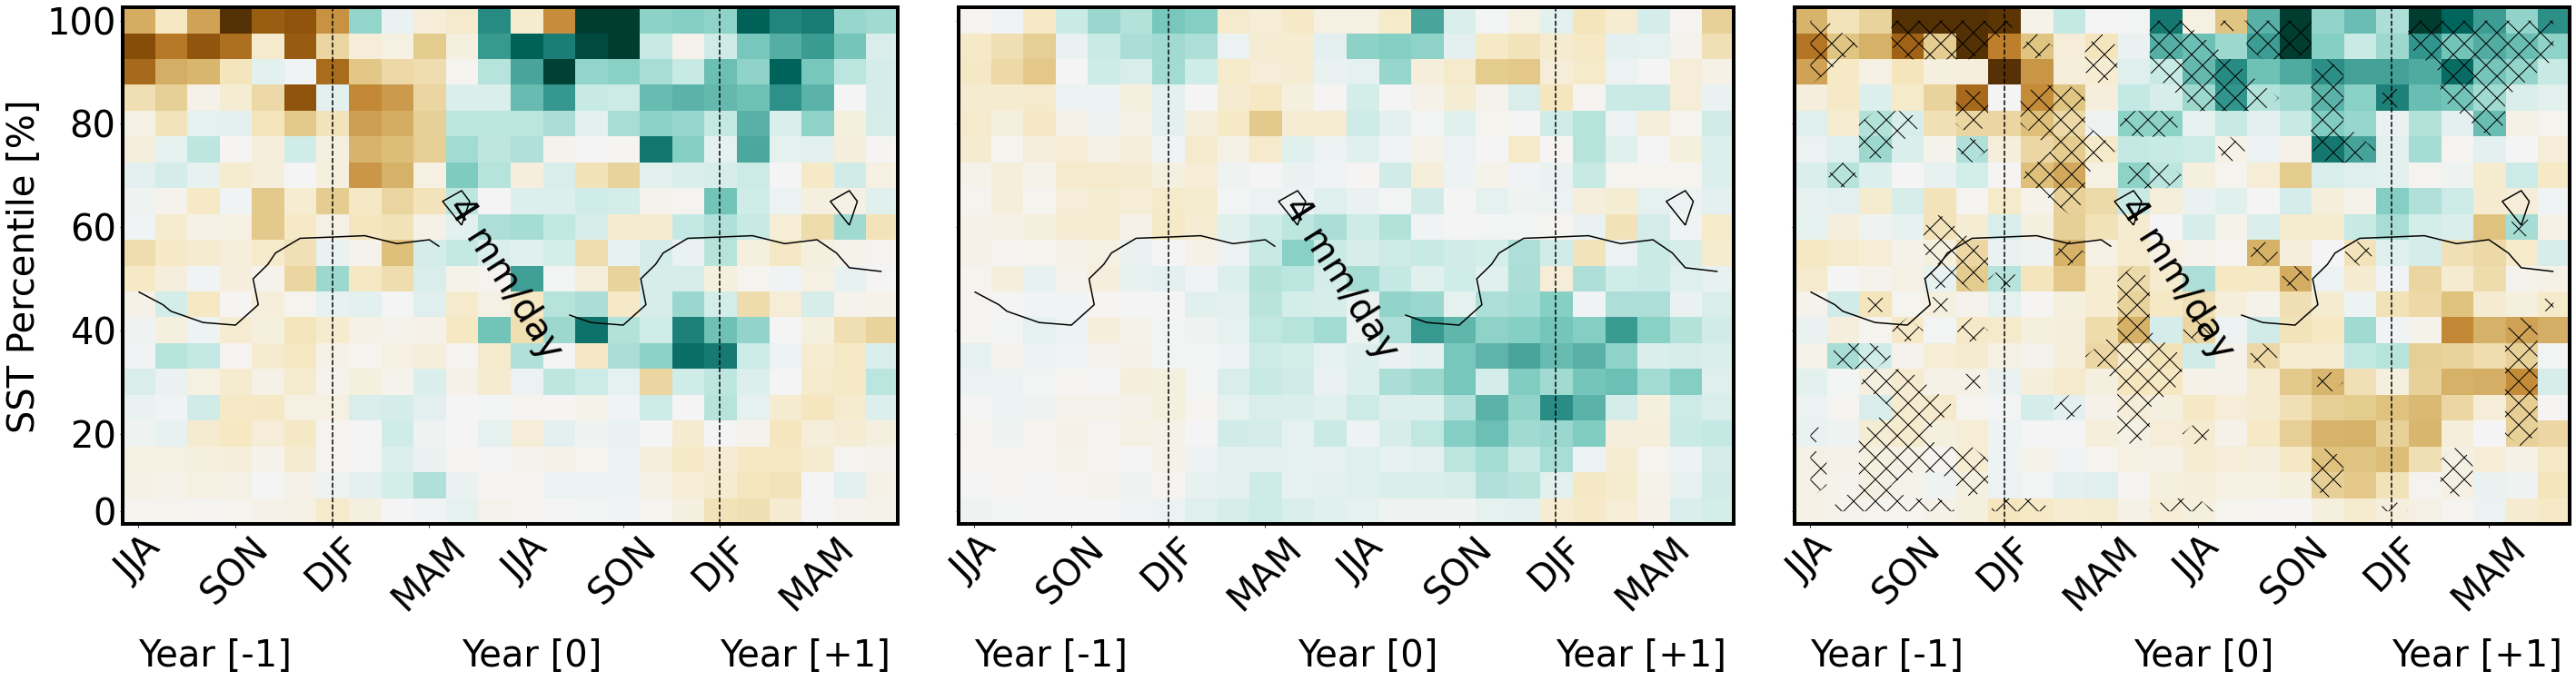

In [17]:
add_cbar = False

# Create the plot
fig, axs = plt.subplots(1,3, figsize=(40, 24), sharex = True, sharey = True)


##----------------------Precip--------------------


# Display the data using imshow
img = axs[0].imshow(
    tp_by_qs, cmap='BrBG', vmin=-2., vmax=2.,
    interpolation='none', origin='lower',
    aspect = .8
)

# Display the data using imshow
img = axs[1].imshow(
    tp_by_qs_compound, cmap='BrBG', vmin=-2., vmax=2.,
    interpolation='none', origin='lower',
    aspect = .8
)

# Display the data using imshow
img= axs[2].imshow(
    tp_by_qs_diff, cmap='BrBG', vmin=-2., vmax=2.,
    interpolation='none', origin='lower',
    aspect = .8
)


# Add color bar with label
if add_cbar:
    cbar = plt.colorbar(img, ax = axs[2], pad=0.02, extend = 'both', shrink = 0.6)
    cbar.set_label('TP Anomaly [mm/day]', fontsize=40, fontweight = 'normal')



comparison = tp_by_qs>all_tp_by_qs
mask_all_five_larger = comparison.all(axis = 0)
mask_at_least_four_larger = comparison.sum(axis = 0) >=5

comparison = tp_by_qs<all_tp_by_qs
mask_all_five_smaller = comparison.all(axis = 0)
mask_at_least_four_smaller = comparison.sum(axis = 0) >=5

#------------------------------hatching
# Add diagonal hatching for significant regions
axs[2].contourf(
    mask_all_five_larger,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['/'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)


# Add diagonal hatching for significant regions
axs[2].contourf(
    mask_at_least_four_larger,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['\\'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)

# Add diagonal hatching for significant regions
axs[2].contourf(
    mask_all_five_smaller,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['/'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)


# Add diagonal hatching for significant regions
axs[2].contourf(
    mask_at_least_four_smaller,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['\\'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)


for ax in axs[:]:
    cs = ax.contour(tp_clim_by_qs, levels = [4], colors = 'k', )
    ax.clabel(cs, cs.levels, fmt = '4 mm/day', fontsize = 40)

##-----------------tuning the graphics------------


# Set y-axis labels
yticks = np.linspace(0, tp_by_qs.shape[0] - 1, 6).astype(int)  # Adjust ticks for clarity
ylabels = np.linspace(0, 100, len(yticks)).astype(int)  # Percentile labels

axs[0].set_yticks(yticks)
axs[0].set_yticklabels(ylabels, fontsize= 40)
axs[0].set_ylabel('SST Percentile [%]', fontsize=40, fontweight = 'normal')

# Set x-axis labels
xticks = [0,3,6,9, 12,15, 18, 21]  # Adjust ticks for clarity
xlabels = ['JJA', 'SON', 'DJF', 'MAM', 'JJA', 'SON', 'DJF', 'MAM']  # Representative months
for ax in axs[:]:
    ax.set_xticks(xticks)
    ax.set_xticklabels(xlabels, rotation = 45, fontsize = 40)
    
for ax in axs[:]:    
    ax.text(0,-6, 'Year [-1]', fontsize = 40, fontweight = 'normal')
    ax.text(10,-6, 'Year [0]', fontsize = 40, fontweight = 'normal')
    ax.text(18,-6, 'Year [+1]', fontsize = 40, fontweight = 'normal')
    

for ax in axs.flatten():
    ax.axvline(6, linestyle = '--', c = 'k')
    ax.axvline(18, linestyle = '--', c = 'k')

# Add a thick frame around the plot
for ax in axs.flatten():   
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(4)


plt.tight_layout()

## SST 

In [18]:
def compute_sst_by_quantiles(sst, start_time, end_time, sst_qs, qs):
    """
    Compute SST values based on quantiles for a given time slice.

    Parameters:
    - sst: xarray DataArray containing SST data.
    - start_time: str, start of the time slice (e.g., '1964-07').
    - end_time: str, end of the time slice (e.g., '1966-06').
    - sst_qs: quantile-based segmentation array.
    - qs: number of quantiles.

    Returns:
    - sst_by_qs: 2D numpy array of shape (qs, time_length), the processed SST values.
    """
    sst_sel = sst.sel(time=slice(start_time, end_time))
    time_length = len(sst_sel.time)
    sst_by_qs = np.zeros((qs, time_length))

    for it in range(time_length):
        month_id = (it + 7) % 12  # Offset month ID
        s = sst_sel.isel(time=it).anom.values

        for iq in range(qs):
            sst_by_qs[iq, it] = (
                np.nanmean(s[sst_qs[month_id] == iq]) - sst_sel.isel(time=it).ocean_mean
            )

    return sst_by_qs

def aggregate_sst_by_quantiles(sst, time_periods, sst_qs, qs):
    """
    Aggregate SST quantile computations over multiple time periods.

    Parameters:
    - sst: xarray DataArray containing SST data.
    - time_periods: list of tuples, each with (start_time, end_time).
    - sst_qs: quantile-based segmentation array.
    - qs: number of quantiles.

    Returns:
    - aggregated_sst_by_qs: 2D numpy array of the mean SST values across all periods.
    """
    all_sst_by_qs = []
    
    for start_time, end_time in time_periods:
        sst_by_qs = compute_sst_by_quantiles(sst, start_time, end_time, sst_qs, qs)
        all_sst_by_qs.append(sst_by_qs)
    
    aggregated_sst_by_qs = np.mean(all_sst_by_qs, axis=0)
    return aggregated_sst_by_qs

In [19]:
fp = '/data/jmex/ERA5/monthly/era5_sst.nc'
sst = decode_time(fp).sel(lat = slice(25,-15), time = slice('1950', '2023'))

sst = sst.where(ocean_mask)

#iport most recent sst data
fp = '/data/jmex/ERA5/monthly/era5_sst24.nc'
sst24 = xr.open_dataset(fp).sel(latitude = (slice(25, -15)))


#change the longitude defintion to 0-360

sst24 = sst24.rename({'latitude':'lat', 'longitude':'lon'})
sst24 = sst24.drop_vars(['number', 'expver'])


sst24 = sst24.rename({'date':'time'})
sst24['time'] = pd.to_datetime(sst24['time'].values.astype(str), format='%Y%m%d')

sst24 = sst24.where(ocean_mask)

# merge the two datasets
sst = xr.concat([sst, sst24], dim = 'time')

#take climatology and anomaly
sst_clim = sst.sel(time = slice('1991', '2020')).groupby('time.month').mean()
sst['anom'] = sst.sst.groupby('time.month') - sst_clim.sst


#rolling mean and mask
sst = sst.rolling(time = 3, center = True, min_periods = 1,).mean()
weights = np.cos(np.deg2rad(sst.lat))
sst['ocean_mean'] = sst.anom.weighted(weights).mean(['lat', 'lon'])

In [20]:
# calculate quantile of data on the climatology
qs = 20
sst_qs = calculate_quantiles(sst_clim.sst.values)


In [21]:
sst_sel = sst.sel(time = slice('2022-07', '2024-06'))
sst_by_qs = np.zeros((qs, 24))

for it in range(len(sst_sel.time)):
    month_id = (it+7)%12 
    s = sst_sel.isel(time = it).anom.values
    
    #loop thorgh each quantile
    for iq in range(qs):

        sst_by_qs[iq, it] = np.nanmean(s[sst_qs[month_id] == iq]) - sst_sel.isel(time = it).ocean_mean 


In [22]:
# Define your time periods
time_periods = [
     ('1990-07', '1992-06'),
    ('1986-07', '1988-06'),
    ('1981-07', '1983-06'),
    ('1996-07', '1998-06'),
    #('2008-07', '2010-06'),
    ('2014-07', '2016-06'),
    # Add more periods as needed
]

# Compute aggregated SST by quantiles
sst_by_qs_compound = aggregate_sst_by_quantiles(sst, time_periods, sst_qs, qs)


In [23]:
#for making the mask: take all events
all_sst_by_qs = np.zeros((len(time_periods), qs, 24))

i = 0
for start_time, end_time in time_periods:
    temp_sst_by_qs = compute_sst_by_quantiles(sst, start_time, end_time, sst_qs, qs)
    all_sst_by_qs[i] = temp_sst_by_qs
    i+=1

In [24]:
sst_by_qs_diff = sst_by_qs-sst_by_qs_compound

In [25]:
#contours

#extend periodically to cover july to jun over 2 years
sst_clim_by_qs = np.zeros((qs, 24))

for it in range(24):
    month_id = (it+7)%12
    s = sst_clim.isel(month = month_id).sst.values
    
    #loop thorgh each quantile
    for iq in range(qs):

        sst_clim_by_qs[iq, it] = np.nanmean(s[sst_qs[month_id] == iq])
        


## Plotting

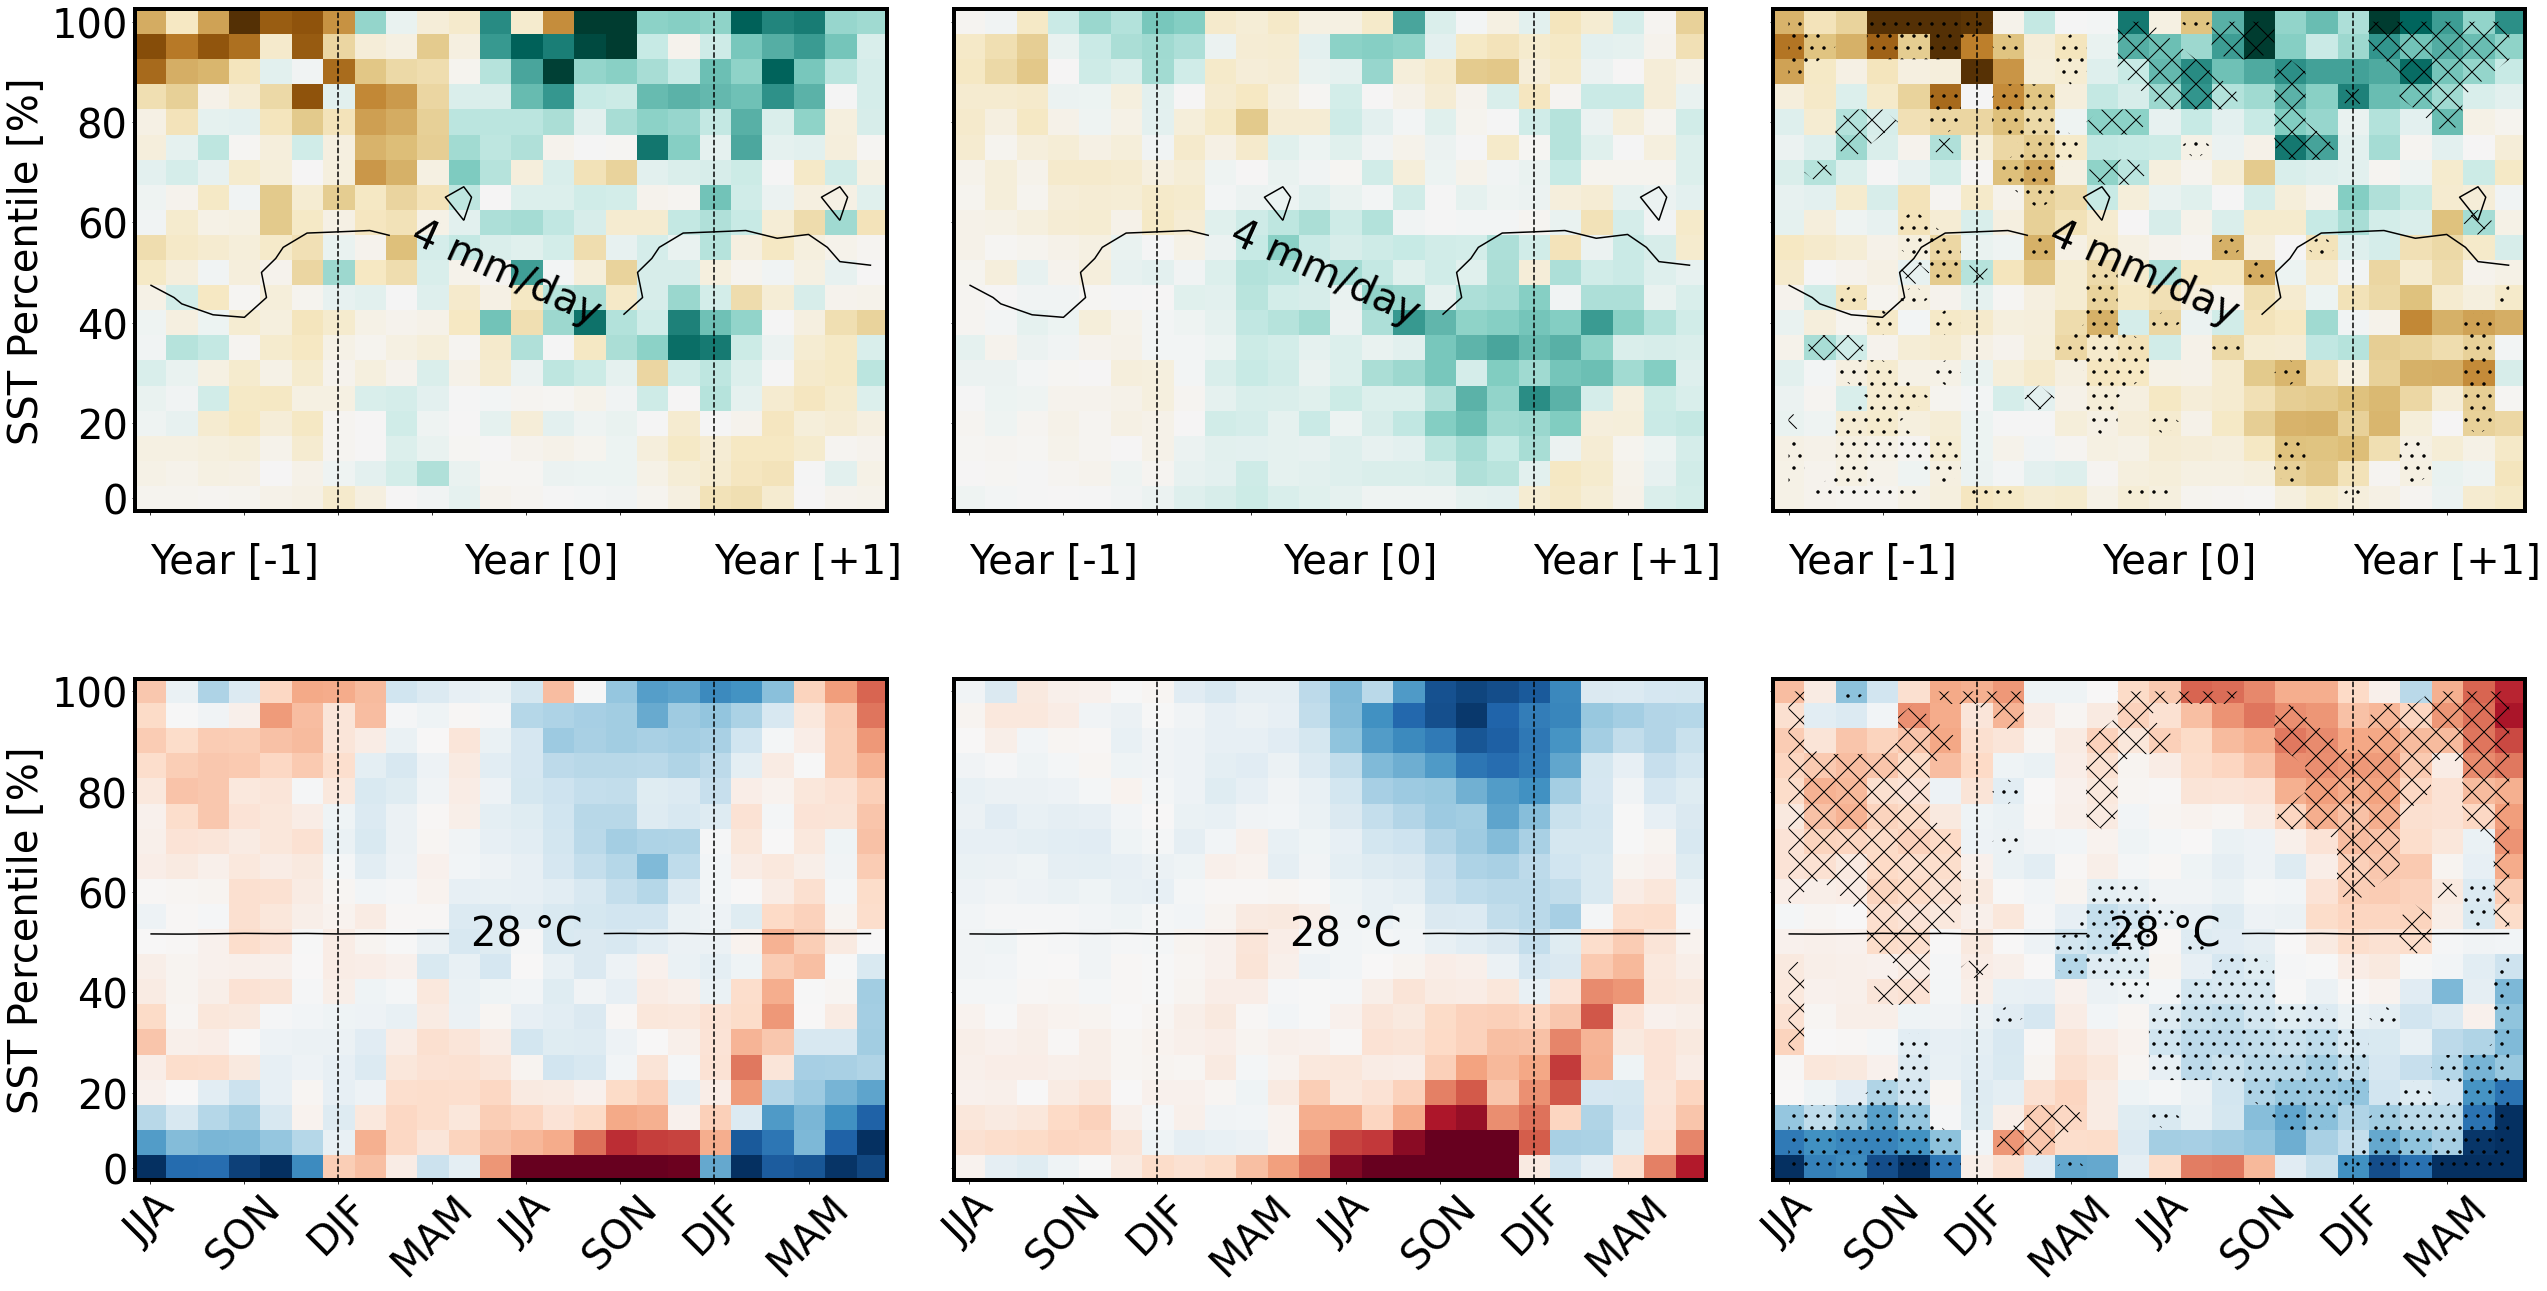

In [27]:
add_cbar = False

# Create the plot
fig, axs = plt.subplots(2,3, figsize=(36, 20), sharex = True, sharey = True)


smax = 0.8

# Display the data using imshow
img = axs[1,0].imshow(
    sst_by_qs, cmap='RdBu_r', vmin = -smax, vmax = smax,
    interpolation='none', origin='lower',
    aspect = .8
)

# Display the data using imshow
img = axs[1,1].imshow(
    sst_by_qs_compound, cmap='RdBu_r', vmin = -smax, vmax = smax,
    interpolation='none', origin='lower',
    aspect = .8
)

# Display the data using imshow
imgs = axs[1,2].imshow(
    sst_by_qs_diff, cmap='RdBu_r', vmin = -smax, vmax = smax,
    interpolation='none', origin='lower',
    aspect = .8
)

# Add color bar with label
if add_cbar:

    cbar = plt.colorbar(imgs, ax=axs[1,2], pad=0.02, extend = 'both', shrink = 0.6)
    cbar.set_label('SST Anomaly [K]', fontsize=40, fontweight = 'normal')


comparison = sst_by_qs>all_sst_by_qs
mask_all_larger = comparison.all(axis = 0)
#mask_at_least_four_larger = comparison.sum(axis = 0) >=5

comparison = sst_by_qs<all_sst_by_qs
mask_all_smaller = comparison.all(axis = 0)
#mask_at_least_four_smaller = comparison.sum(axis = 0) >=5

#------------------------------hatching
#hatching
# Add diagonal hatching for significant regions
axs[1,2].contourf(
    mask_all_larger,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['/'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)


# Add diagonal hatching for significant regions
axs[1,2].contourf(
    mask_all_larger,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['\\'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)


# Add diagonal hatching for significant regions
axs[1,2].contourf(
    mask_all_smaller,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['.'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)
##----------------------Precip--------------------


# Display the data using imshow
img = axs[0,0].imshow(
    tp_by_qs, cmap='BrBG', vmin=-2., vmax=2.,
    interpolation='none', origin='lower',
    aspect = .8
)

# Display the data using imshow
img = axs[0,1].imshow(
    tp_by_qs_compound, cmap='BrBG', vmin=-2., vmax=2.,
    interpolation='none', origin='lower',
    aspect = .8
)

# Display the data using imshow
img= axs[0,2].imshow(
    tp_by_qs_diff, cmap='BrBG', vmin=-2., vmax=2.,
    interpolation='none', origin='lower',
    aspect = .8
)


# Add color bar with label
if add_cbar:
    cbar = plt.colorbar(img, ax = axs[0,2], pad=0.02, extend = 'both', shrink = 0.6)
    cbar.set_label('TP Anomaly [mm/day]', fontsize=40, fontweight = 'normal')




comparison = tp_by_qs>all_tp_by_qs
mask_all_larger = comparison.all(axis = 0)
#mask_at_least_four_larger = comparison.sum(axis = 0) >=5

comparison = tp_by_qs<all_tp_by_qs
mask_all_smaller = comparison.all(axis = 0)
#mask_at_least_four_smaller = comparison.sum(axis = 0) >=5

#------------------------------hatching
#hatching
# Add diagonal hatching for significant regions
axs[0,2].contourf(
    mask_all_larger,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['/'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)


# Add diagonal hatching for significant regions
axs[0,2].contourf(
    mask_all_larger,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['\\'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)

# Add diagonal hatching for significant regions
axs[0,2].contourf(
    mask_all_smaller,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['.'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)



for ax in axs[1,:]:
    cs = ax.contour(sst_clim_by_qs-273.15, levels = [28], colors = 'k', )
    ax.clabel(cs, cs.levels, fmt = '28 °C', fontsize = 40)
    
    
for ax in axs[0,:]:
    cs = ax.contour(tp_clim_by_qs, levels = [4], colors = 'k', )
    ax.clabel(cs, cs.levels, fmt = '4 mm/day', fontsize = 40)

##-----------------tuning the graphics------------


# Set y-axis labels
yticks = np.linspace(0, tp_by_qs.shape[0] - 1, 6).astype(int)  # Adjust ticks for clarity
ylabels = np.linspace(0, 100, len(yticks)).astype(int)  # Percentile labels
for ax in axs[:,0]:
    ax.set_yticks(yticks)
    ax.set_yticklabels(ylabels, fontsize= 40)
    ax.set_ylabel('SST Percentile [%]', fontsize=40, fontweight = 'normal')

# Set x-axis labels
xticks = [0,3,6,9, 12,15, 18, 21]  # Adjust ticks for clarity
xlabels = ['JJA', 'SON', 'DJF', 'MAM', 'JJA', 'SON', 'DJF', 'MAM']  # Representative months
for ax in axs[1,:]:
    ax.set_xticks(xticks)
    ax.set_xticklabels(xlabels, rotation = 45, fontsize = 40)
    
for ax in axs[0,:]:    
    ax.text(0,-3, 'Year [-1]', fontsize = 40, fontweight = 'normal')
    ax.text(10,-3, 'Year [0]', fontsize = 40, fontweight = 'normal')
    ax.text(18,-3, 'Year [+1]', fontsize = 40, fontweight = 'normal')
    

for ax in axs.flatten():
    ax.axvline(6, linestyle = '--', c = 'k')
    ax.axvline(18, linestyle = '--', c = 'k')

# Add a thick frame around the plot
for ax in axs.flatten():   
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(4)


plt.tight_layout()
fig.savefig('Figures/Fig3a.png', dpi = 600, format = 'png')


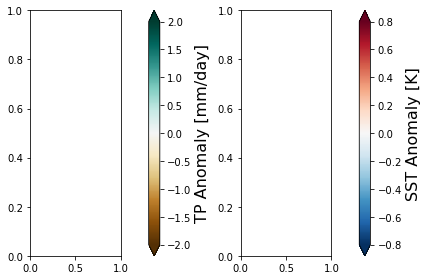

In [28]:
fig, [ax1,ax2] = plt.subplots(1,2)

cbar = plt.colorbar(img, ax = ax1, pad=0.2, extend = 'both', shrink = 1)
cbar.set_label('TP Anomaly [mm/day]', fontsize=16, fontweight = 'normal')

cbar = plt.colorbar(imgs, ax = ax2, pad=0.2, extend = 'both', shrink = 1)
cbar.set_label('SST Anomaly [K]', fontsize=16, fontweight = 'normal')

plt.tight_layout()
fig.savefig('Figures/Fig3acbar.png', dpi = 600, format = 'png')
